# GPT-2 Large & Llama 3.1 8B — Semantic Similarity Results

## Research question

Can causal (left-to-right) language models recover word sense structure well enough to rival bidirectional encoders on human-elicited semantic similarity benchmarks, when equipped with a multi-prototype representation strategy?

This notebook assembles and compares results across three embedding strategies applied to two decoder-only LLMs:

| Strategy | Description |
|---|---|
| **Non-contextual** | Word embedded in isolation; no surrounding sentence |
| **Simple context** | Word embedded in a fixed template sentence; single vector per word |
| **Multi-prototype (MaxSim)** | Word embedded across many BNC corpus sentences; K-means clusters capture distinct senses |

The multi-prototype method replicates [Chronis & Erk (2020)](https://aclanthology.org/2020.conll-1.7), which originally applied this approach to BERT-base. Our contribution is applying the same pipeline to GPT-2 Large (774M parameters, causal decoder) and Llama 3.1 8B (8B parameters, causal decoder), and evaluating against both SimLex-999 (semantic similarity) and MEN (semantic relatedness).

## Workflow

All embedding computation and clustering happen in the two upstream notebooks:
- `gpt2_cluster_analysis.ipynb` — GPT-2 Large embeddings, K-means sweep, per-layer ρ
- `llama_cluster_analysis.ipynb` — Llama 3.1 8B embeddings, K-means sweep, per-layer ρ

This notebook only loads the saved CSVs and computes summary statistics.

**Expected CSVs (run the cluster notebooks first):**
- `results_gpt2_nonctx.csv`, `results_llama_nonctx.csv` — non-contextual baselines (layer 0 and final)
- `results_gpt2_simple_simlex.csv`, `results_gpt2_simple_men.csv` — GPT-2 simple template, per-layer ρ
- `results_llama_simple_simlex.csv`, `results_llama_simple_men.csv` — Llama simple template, per-layer ρ
- `results_gpt2_simlex.csv`, `results_gpt2_men.csv` — GPT-2 K × layer MaxSim heatmaps
- `results_llama_simlex.csv`, `results_llama_men.csv` — Llama K × layer MaxSim heatmaps

In [1]:
import os
import sys
sys.path.insert(0, 'src')
import datasets
import numpy as np
import pandas as pd

## Load Datasets

We evaluate on two standard word-pair benchmarks that measure different aspects of lexical meaning:

### SimLex-999 (Hill et al., 2015)
- **999 word pairs** (333 noun, 333 verb, 333 adjective pairs)
- Measures **semantic similarity**: the degree to which two words can *substitute* for each other in context (e.g., *cat* ≈ *kitten*, but *cat* ≉ *mouse*)
- Human annotators were explicitly instructed to distinguish similarity from association/relatedness
- Scores range from 0–10; the benchmark Spearman correlation is computed against model cosine similarities
- Considered a harder benchmark for distributional models because relatedness cues (co-occurrence) do not directly signal similarity

### MEN (Bruni et al., 2014)
- **3,000 word pairs** drawn from a diverse vocabulary
- Measures **semantic relatedness**: a broader notion that includes association, taxonomic, and topical links (e.g., *coffee* ~ *cup* or *beach* ~ *ocean*)
- Annotated via pairwise ranking by crowd-sourced workers; scores normalized to [0, 50]
- Relatedness is generally easier for distributional models since co-occurrence patterns capture topical proximity

**Key distinction:** A model can score well on MEN by capturing topic/domain clusters, but must recover finer-grained sense structure to score well on SimLex-999. Strong SimLex performance is a better indicator of lexical semantic quality.

In [2]:
simlex999 = datasets.get_simlex999()
men = datasets.get_men()
print(f"SimLex-999: {len(simlex999)} pairs")
print(f"MEN: {len(men)} pairs")

processed 999 word pairs from simlex999 dataset
processed 3000 word pairs from MEN relatedness dataset
SimLex-999: 999 pairs
MEN: 3000 pairs


## Non-contextual Baselines

Each word is embedded in complete isolation — no surrounding sentence is provided. This strips out any contextual signal and lets us measure what the model's parameters contain *without* the attention mechanism integrating cross-token information.

Two variants are compared:

| Variant | How it's extracted | Analogy |
|---|---|---|
| **Layer 0** | `hidden_states[0]` — output of the embedding matrix only | Similar to static GloVe / word2vec |
| **Final layer** | `last_hidden_state` — full forward pass over a single token | Upper representation without context |

**Why these matter:**
- The layer-0 baseline tells us how much semantic structure is already baked into the learned token embeddings before any transformer computation.
- The final-layer baseline reveals whether the transformer layers *on their own* (absent sentence context) improve or degrade the embedding quality — for causal models, later layers increasingly model *prediction* rather than static meaning, so final-layer non-contextual embeddings may actually be *worse* than layer 0 on similarity tasks.
- Together they bound the range of what can be attributed to architecture vs. context.

Results are loaded from `results_gpt2_nonctx.csv` and `results_llama_nonctx.csv`, produced at the end of each cluster notebook.

In [3]:
def best_from_csv(path):
    if not os.path.exists(path):
        return None, None
    df = pd.read_csv(path, index_col=0)
    best_layer = int(df['spearman'].idxmax())
    best_rho = float(df['spearman'].max())
    return best_rho, best_layer


gpt2_nonctx  = pd.read_csv('results/results_gpt2_nonctx.csv',  index_col=0) if os.path.exists('results/results_gpt2_nonctx.csv')  else None
llama_nonctx = pd.read_csv('results/results_llama_nonctx.csv', index_col=0) if os.path.exists('results/results_llama_nonctx.csv') else None

if gpt2_nonctx is not None:
    print("GPT-2 Large — non-contextual:")
    display(gpt2_nonctx)
else:
    print("results_gpt2_nonctx.csv not found — run gpt2_cluster_analysis.ipynb first")

if llama_nonctx is not None:
    print("\nLlama 3.1 8B — non-contextual:")
    display(llama_nonctx)
else:
    print("results_llama_nonctx.csv not found — run llama_cluster_analysis.ipynb first")

GPT-2 Large — non-contextual:


,simlex_rho,men_rho
embedding,,
initial_layer_0,0.0952,0.1081
final_layer,0.0940,0.3332



Llama 3.1 8B — non-contextual:


,simlex_rho,men_rho
embedding,,
initial_layer_0,-0.0921,0.0989
final_layer,0.1393,0.3262


## Simple Contextualized Embeddings

Each target word is embedded inside the fixed template sentence **"The {word} is here."** This provides a minimal, semantically neutral sentential context that activates the model's attention mechanism without biasing the representation toward any particular topic or sense.

**Why a fixed template?**
- Guarantees that all words receive *identical* surrounding context, so differences in cosine similarity between word pairs are driven entirely by the target token representations, not by variation in sentence topic.
- Makes this condition directly comparable across words and models.
- Serves as an intermediate step between pure non-contextual (no sentence) and full multi-prototype (many naturalistic sentences).

**Per-layer sweep:**
Transformer layers specialize across depth: early layers tend to encode surface/syntactic properties; middle layers often capture broad semantic categories; upper layers increasingly encode the model's predictive context. Because the optimal layer for semantic similarity is not known in advance, we sweep all layers and report the **best-layer** Spearman ρ for each model × dataset pair.

**Limitation:** A single vector per word cannot represent polysemy — a word like *bank* (financial institution vs. river bank) produces one averaged representation regardless of which sense would be most relevant for a given word pair. The MaxSim method below addresses this.

Results are loaded from the per-layer CSVs produced by the cluster notebooks.

In [4]:
simple_rows = []
for model, prefix in [('GPT-2 Large', 'gpt2'), ('Llama 3.1 8B', 'llama')]:
    rho_s, layer_s = best_from_csv(f'results/results_{prefix}_simple_simlex.csv')
    rho_m, layer_m = best_from_csv(f'results/results_{prefix}_simple_men.csv')
    simple_rows.append({
        'Model': model,
        'SimLex-999 ρ': round(rho_s, 4) if rho_s is not None else '—',
        'SimLex-999 best layer': layer_s if layer_s is not None else '—',
        'MEN ρ': round(rho_m, 4) if rho_m is not None else '—',
        'MEN best layer': layer_m if layer_m is not None else '—',
    })

df_simple = pd.DataFrame(simple_rows).set_index('Model')
display(df_simple)

,SimLex-999 ρ,SimLex-999 best layer,MEN ρ,MEN best layer
Model,,,,
GPT-2 Large,0.501,17,0.679,7
Llama 3.1 8B,0.454,21,0.723,6


## Complex Contextualized Embeddings (Multi-Prototype MaxSim)

This is the main experiment, replicating the methodology of:

> Chronis, G., & Erk, K. (2020). [When is a bishop not a bishop? Interpreting visually grounded agreement with referring expressions](https://aclanthology.org/2020.conll-1.7). *Proceedings of CoNLL 2020.*

### Method overview

1. **Corpus retrieval:** For each target word, sentences containing that word are drawn from the British National Corpus (BNC), a 100M-word balanced corpus of written and spoken British English.
2. **Contextual embedding:** Each sentence is passed through the model; the hidden state at the target word's token position is extracted for each transformer layer.
3. **K-means clustering:** The set of sentence vectors for a word at a given layer is clustered into *K* groups. Each cluster centroid represents a prototype — a distinct usage pattern or sense of the word. K is swept from 1 to 8.
4. **MaxSim scoring:** For a word pair (w₁, w₂), similarity is computed as:

$$\text{MaxSim}(w_1, w_2) = \max_{c_1 \in C(w_1),\; c_2 \in C(w_2)} \cos(c_1, c_2)$$

where C(wᵢ) is the set of cluster centroids for word *i*. This selects the most compatible pair of senses, which is appropriate for similarity judgments (two words are similar if *any* of their senses are similar).

5. **Evaluation:** Spearman ρ between model MaxSim scores and human similarity ratings, computed for each (K, layer) combination. The K × layer heatmap is saved as a CSV.

### Why this helps
Polysemous words accumulate many distinct sentence embeddings that span multiple regions of representation space. A single mean vector smears these together; K-means prototypes preserve the separation. MaxSim then matches the nearest-sense pair, avoiding false-low scores when words share a niche sense but diverge on their dominant sense.

### Hyperparameter grid
- **K** ∈ {1, 2, 3, 4, 5, 6, 7, 8} — number of prototypes per word
- **Layer** — all transformer layers (GPT-2 Large: 37 layers; Llama 3.1 8B: 33 layers)

The cell below loads the best (K, layer) result for each model × dataset combination from the saved heatmap CSVs.

In [5]:
def best_csv_rho(path):
    if not os.path.exists(path):
        return None, '— (CSV not found)'
    df = pd.read_csv(path, index_col=0)
    df.columns = df.columns.astype(int)
    idx_flat = df.values.argmax()
    k_i, l_i = divmod(idx_flat, df.shape[1])
    rho = float(df.values.max())
    k, layer = int(df.index[k_i]), int(df.columns[l_i])
    return rho, f'K={k}, layer {layer}'

cluster_results = []
for label, path_s, path_m in [
    ('GPT-2 Large — MaxSim (multi-prototype)',  'results/results_gpt2_simlex.csv',  'results/results_gpt2_men.csv'),
    ('Llama 3.1 8B — MaxSim (multi-prototype)', 'results/results_llama_simlex.csv', 'results/results_llama_men.csv'),
]:
    rho_s, best_s = best_csv_rho(path_s)
    rho_m, best_m = best_csv_rho(path_m)
    cluster_results.append((label, rho_s, best_s, rho_m, best_m))
    rho_s_str = f'{rho_s:.4f}' if rho_s is not None else '—'
    rho_m_str = f'{rho_m:.4f}' if rho_m is not None else '—'
    print(f"{label}")
    print(f"  SimLex-999  ρ={rho_s_str}  ({best_s})")
    print(f"  MEN         ρ={rho_m_str}  ({best_m})")
    print()

GPT-2 Large — MaxSim (multi-prototype)
  SimLex-999  ρ=0.5740  (K=6, layer 17)
  MEN         ρ=0.7250  (K=1, layer 0)

Llama 3.1 8B — MaxSim (multi-prototype)
  SimLex-999  ρ=0.6110  (K=6, layer 6)
  MEN         ρ=0.7750  (K=2, layer 6)



## Full Comparison

All methods together: non-contextual baselines, simple contextualized embeddings, and the multi-prototype MaxSim results, alongside Chronis & Erk's BERT-base result from the 2020 CoNLL paper.

### How to read the table

- **Spearman ρ** measures rank correlation between model cosine similarities and human ratings. ρ = 1.0 is perfect; ρ = 0 is chance. Values ≥ 0.5 on SimLex-999 are generally considered competitive.
- Each row reports the **best** result for that method — the optimal layer for simple context, or the optimal (K, layer) pair for MaxSim. Results are therefore upper bounds on what each strategy can achieve; they are *not* the result of a fixed hyperparameter.
- The BERT-base row is the reference from Chronis & Erk (2020). Fill in the paper's reported ρ values to enable direct comparison.

### Architectural context

| Model | Parameters | Architecture | Attention |
|---|---|---|---|
| BERT-base | 110M | Encoder-only | Bidirectional |
| GPT-2 Large | 774M | Decoder-only | Causal (left-to-right) |
| Llama 3.1 8B | 8B | Decoder-only | Causal (left-to-right) |

The comparison is **not size-controlled** — Llama 3.1 8B is roughly 73× larger than BERT-base. The hypothesis being tested is whether causal architecture *structurally disadvantages* models on static-word similarity tasks relative to BERT's full bidirectional context window, and whether the multi-prototype strategy can close that gap regardless of scale.

In [6]:
# === Chronis & Erk (2020) BERT-base results
CHRONIS_ERK_SIMLEX = 0.608  
CHRONIS_ERK_MEN    = 0.793

def best_csv_rho(path):
    if not os.path.exists(path):
        return None, '— (CSV not found)'
    df = pd.read_csv(path, index_col=0)
    df.columns = df.columns.astype(int)
    idx_flat = df.values.argmax()
    k_i, l_i = divmod(idx_flat, df.shape[1])
    rho = float(df.values.max())
    k, layer = int(df.index[k_i]), int(df.columns[l_i])
    return rho, f'K={k}, layer {layer}'


summary_rows = []

# Non-contextual baselines
for model, prefix in [('GPT-2 Large', 'gpt2'), ('Llama 3.1 8B', 'llama')]:
    df_nc = (pd.read_csv(f'results/results_{prefix}_nonctx.csv', index_col=0)
             if os.path.exists(f'results/results_{prefix}_nonctx.csv') else None)
    for emb_type, label_suffix in [('initial_layer_0', 'initial (layer 0)'),
                                    ('final_layer',     'final layer (no context)')]:
        if df_nc is not None and emb_type in df_nc.index:
            summary_rows.append({
                'Model / Method': f'{model} — {label_suffix}',
                'SimLex-999 ρ': df_nc.loc[emb_type, 'simlex_rho'],
                'MEN ρ':        df_nc.loc[emb_type, 'men_rho'],
                'Best config':  'non-contextual',
            })
        else:
            summary_rows.append({
                'Model / Method': f'{model} — {label_suffix}',
                'SimLex-999 ρ': '—', 'MEN ρ': '—', 'Best config': '—',
            })

# Simple contextualized (best layer)
for model, prefix in [('GPT-2 Large', 'gpt2'), ('Llama 3.1 8B', 'llama')]:
    rho_s, layer_s = best_from_csv(f'results/results_{prefix}_simple_simlex.csv')
    rho_m, layer_m = best_from_csv(f'results/results_{prefix}_simple_men.csv')
    summary_rows.append({
        'Model / Method': f'{model} — simple context (best layer)',
        'SimLex-999 ρ': round(rho_s, 4) if rho_s is not None else '—',
        'MEN ρ':        round(rho_m, 4) if rho_m is not None else '—',
        'Best config':  (f'SimLex layer {layer_s}; MEN layer {layer_m}'
                         if layer_s is not None else '—'),
    })

# MaxSim multi-prototype (best K, layer)
for model, prefix in [('GPT-2 Large', 'gpt2'), ('Llama 3.1 8B', 'llama')]:
    rho_s, best_s = best_csv_rho(f'results/results_{prefix}_simlex.csv')
    rho_m, best_m = best_csv_rho(f'results/results_{prefix}_men.csv')
    summary_rows.append({
        'Model / Method': f'{model} — MaxSim multi-prototype',
        'SimLex-999 ρ': round(rho_s, 4) if rho_s is not None else '—',
        'MEN ρ':        round(rho_m, 4) if rho_m is not None else '—',
        'Best config':  f'SimLex {best_s}; MEN {best_m}',
    })

# BERT-base (Chronis & Erk 2020)
summary_rows.append({
    'Model / Method': 'BERT-base — MaxSim (Chronis & Erk 2020)',
    'SimLex-999 ρ': CHRONIS_ERK_SIMLEX if CHRONIS_ERK_SIMLEX is not None else '- (fill in)',
    'MEN ρ':        CHRONIS_ERK_MEN    if CHRONIS_ERK_MEN    is not None else '— (fill in)',
    'Best config':  'SimLex K=5, layer 8; MEN K=9, layer 11',
})

df_summary = pd.DataFrame(summary_rows).set_index('Model / Method')
display(df_summary)

,SimLex-999 ρ,MEN ρ,Best config
Model / Method,,,
GPT-2 Large — initial (layer 0),0.0952,0.1081,non-contextual
GPT-2 Large — final layer (no context),0.0940,0.3332,non-contextual
Llama 3.1 8B — initial (layer 0),-0.0921,0.0989,non-contextual
Llama 3.1 8B — final layer (no context),0.1393,0.3262,non-contextual
GPT-2 Large — simple context (best layer),0.5010,0.6790,SimLex layer 17; MEN layer 7
Llama 3.1 8B — simple context (best layer),0.4540,0.7230,SimLex layer 21; MEN layer 6
GPT-2 Large — MaxSim multi-prototype,0.5740,0.7250,"SimLex K=6, layer 17; MEN K=1, layer 0"
Llama 3.1 8B — MaxSim multi-prototype,0.6110,0.7750,"SimLex K=6, layer 6; MEN K=2, layer 6"
BERT-base — MaxSim (Chronis & Erk 2020),0.6080,0.7930,"SimLex K=5, layer 8; MEN K=9, layer 11"


## Model size maybe does matter after all. 
Should we try smaller versions of each model next, with a similar parameter counts to BERT base, for a proper comparison of architectures? It's alright streaking how much larger causal models have to be to match BERT on these tasks. But in terms of performance, it's at least possible to get close or even do better.

## Also note something something important about the layer probing. 
The hypothesis that panned out in Chronis and Erk (2020)'s analysis of BERT was that knowledge of word similarity shows up in earlier layers (SimLex task), while knowledge of word relatedness shows up in later layers (MEN). But visual inspection of the results show that this isn't the case for causal models when using the clustering method. Word similarity and relatedness are mixed in the distributed representation of meaning.

## Per-layer Spearman ρ — Multi-Prototype vs. Simple Template

One line per method per model, across all layers. The multi-prototype line uses K=4 (a representative mid-range value). Shaded region marks the peak layer for each multi-prototype curve.

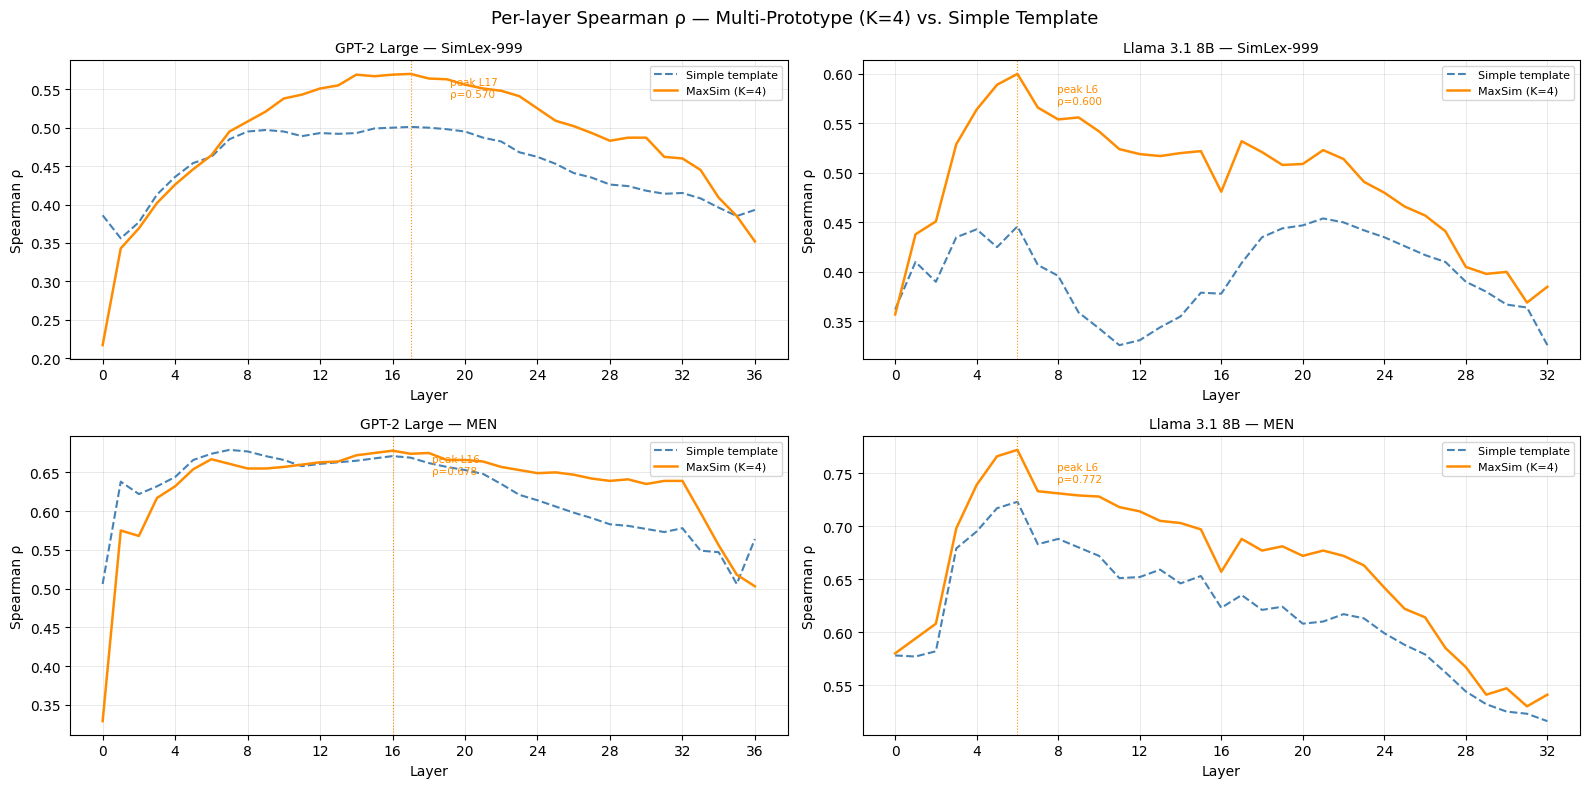

Saved → results/per_layer_comparison.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

K_PLOT = 4  # representative K for the per-layer multi-prototype line

configs = [
    ('GPT-2 Large',   'gpt2',  36),
    ('Llama 3.1 8B',  'llama', 32),
]
datasets_cfg = [
    ('SimLex-999', 'simlex', 'SimLex999'),
    ('MEN',        'men',    'relatedness'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharey=False)
fig.suptitle('Per-layer Spearman ρ — Multi-Prototype (K=4) vs. Simple Template', fontsize=13)

for col, (model_label, prefix, max_layer) in enumerate(configs):
    for row, (task_label, task_key, _) in enumerate(datasets_cfg):
        ax = axes[row, col]

        # Simple template
        simple_path = f'results/results_{prefix}_simple_{task_key}.csv'
        if os.path.exists(simple_path):
            df_s = pd.read_csv(simple_path, index_col=0)
            ax.plot(df_s.index, df_s['spearman'], label='Simple template',
                    color='steelblue', linewidth=1.5, linestyle='--')

        # Multi-prototype K=K_PLOT
        mp_path = f'results/results_{prefix}_{task_key}.csv'
        if os.path.exists(mp_path):
            df_mp = pd.read_csv(mp_path, index_col=0)
            df_mp.columns = df_mp.columns.astype(int)
            if K_PLOT in df_mp.index:
                row_vals = df_mp.loc[K_PLOT]
                ax.plot(row_vals.index, row_vals.values, label=f'MaxSim (K={K_PLOT})',
                        color='darkorange', linewidth=1.8)
                peak_layer = int(row_vals.idxmax())
                peak_rho   = float(row_vals.max())
                ax.axvline(peak_layer, color='darkorange', linewidth=0.8, linestyle=':')
                ax.annotate(f'peak L{peak_layer}\nρ={peak_rho:.3f}',
                            xy=(peak_layer, peak_rho),
                            xytext=(peak_layer + max_layer * 0.06, peak_rho - 0.03),
                            fontsize=7.5, color='darkorange')

        ax.set_title(f'{model_label} — {task_label}', fontsize=10)
        ax.set_xlabel('Layer')
        ax.set_ylabel('Spearman ρ')
        ax.xaxis.set_major_locator(mticker.MultipleLocator(4))
        ax.legend(fontsize=8)
        ax.grid(True, linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig('results/per_layer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/per_layer_comparison.png")

## Summary Bar Chart — All Methods

Best Spearman ρ per method, grouped by dataset. BERT-base (Chronis & Erk 2020) shown as a dashed reference line.

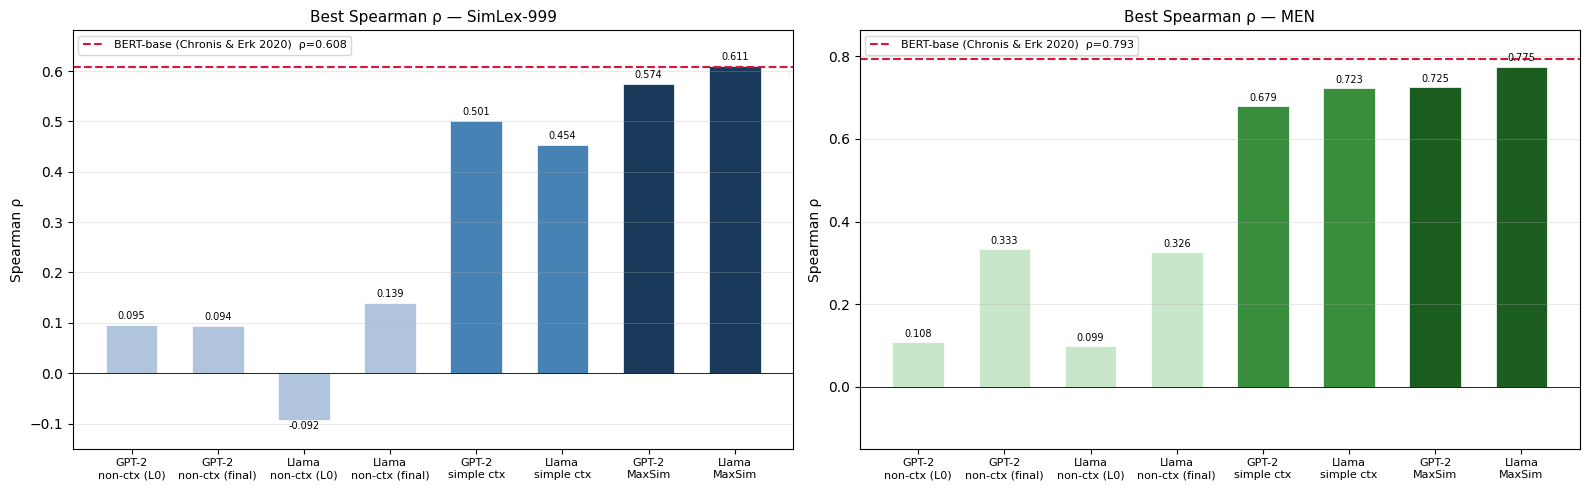

Saved → results/summary_bar_chart.png


In [8]:
import numpy as np

# --- data ---
methods = [
    'GPT-2\nnon-ctx (L0)',
    'GPT-2\nnon-ctx (final)',
    'Llama\nnon-ctx (L0)',
    'Llama\nnon-ctx (final)',
    'GPT-2\nsimple ctx',
    'Llama\nsimple ctx',
    'GPT-2\nMaxSim',
    'Llama\nMaxSim',
]

simlex_vals = [0.0952, 0.0940, -0.0921, 0.1393, 0.501, 0.454, 0.574, 0.611]
men_vals    = [0.1081, 0.3332,  0.0989, 0.3262, 0.679, 0.723, 0.725, 0.775]

# BERT-base reference (Chronis & Erk 2020)
bert_simlex = CHRONIS_ERK_SIMLEX
bert_men    = CHRONIS_ERK_MEN

x = np.arange(len(methods))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

colors_simlex = ['#b0c4de'] * 4 + ['#4682b4'] * 2 + ['#1a3a5c'] * 2
colors_men    = ['#c8e6c9'] * 4 + ['#388e3c'] * 2 + ['#1b5e20'] * 2

for ax, vals, colors, task, bert_ref in [
    (axes[0], simlex_vals, colors_simlex, 'SimLex-999', bert_simlex),
    (axes[1], men_vals,    colors_men,    'MEN',        bert_men),
]:
    bars = ax.bar(x, vals, width=0.6, color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(bert_ref, color='crimson', linewidth=1.5, linestyle='--',
               label=f'BERT-base (Chronis & Erk 2020)  ρ={bert_ref}')
    ax.set_xticks(x)
    ax.set_xticklabels(methods, fontsize=8)
    ax.set_ylabel('Spearman ρ')
    ax.set_title(f'Best Spearman ρ — {task}', fontsize=11)
    ax.set_ylim(min(min(vals) - 0.05, -0.15), max(max(vals), bert_ref) + 0.07)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.legend(fontsize=8)
    ax.grid(axis='y', linewidth=0.4, alpha=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + (0.008 if v >= 0 else -0.022),
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('results/summary_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/summary_bar_chart.png")

## Save Summary Tables

In [ ]:
# Simple contextualized embeddings — best layer per model × dataset
df_simple.to_csv('results/summary_simple_context.csv')
print("Saved → results/summary_simple_context.csv")

# Full comparison — all methods, both datasets, with BERT-base reference
df_summary.to_csv('results/summary_all_methods.csv')
print("Saved → results/summary_all_methods.csv")